<a href="https://colab.research.google.com/github/AbdulMuizz789/PixelFinder/blob/main/PixelFind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL based Pixel Prediction

In [1]:
#Import statements
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

## Dataset
Generated all possible 50x50 grayscale images. All pixels are set to 0 (black), apart from a single pixel set to 255 (white). As the problem space is small (50x50 = 2,500 images), hence it is viable to generate these images. It also ensures *generalization* (no bias due to repeated images).

All the generated images are stored in a list in memory as a 2D array, making them easier to process.

The image pixel values are then normalized to range [0,1]. The coordinates are also normalized to [0,1] to enable regression and higher convergence. The data is then split into training and validation datasets, where 80% of original data is used for training and the other 20% is used for validation.

In [2]:


"""Return generated images along with coordinates of the white pixel."""
def generate_images(img_size=50):
    num_images = img_size * img_size
    images = np.zeros((num_images, img_size, img_size, 1), np.uint8)
    coords = np.zeros((num_images, 2), np.float32)

    i = 0
    for x in range(img_size):
        for y in range(img_size):
            images[i, y, x, 0] = 255
            coords[i] = [x / (img_size - 1), y / (img_size - 1)]
            i += 1

    return images, coords



In [3]:
#Store dataset, X -> images, Y-> coordinates
with generate_images() as (X, Y):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))

#Normalize data
normalize_layer = layers.Rescaling(1./255)
dataset = dataset.map(lambda x, y: (normalize_layer(x), y))

#Training and Validation data split
train_dataset, test_dataset = keras.utils.split_dataset(dataset, left_size=0.8,
                                                        shuffle=True)

#Add batching
train_dataset = train_dataset.batch(32)
test_dataset = test_dataset.batch(32)

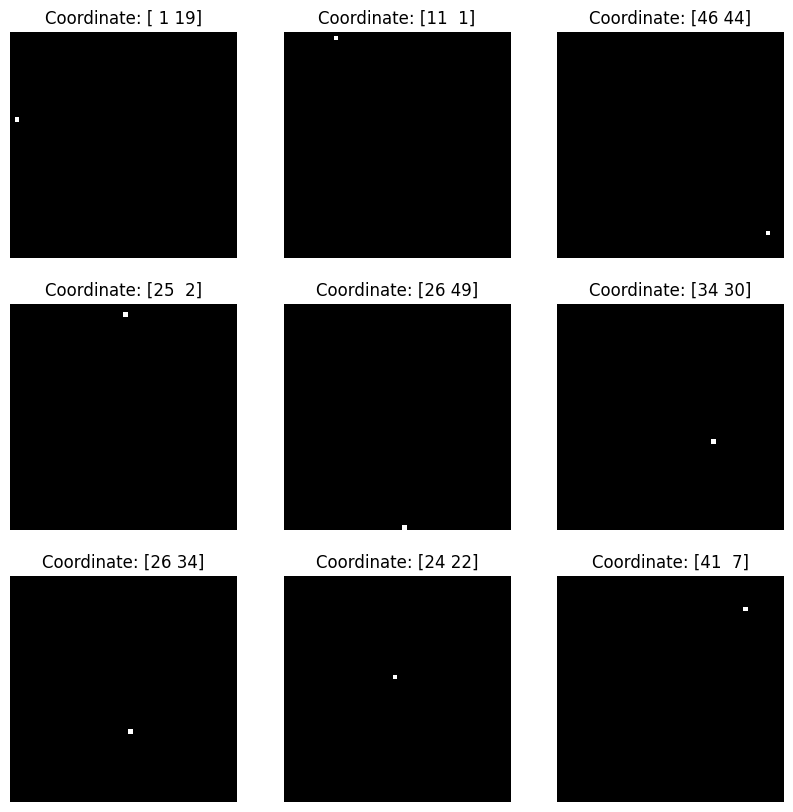

In [4]:
#Show first 9 images
plt.figure(figsize = (10, 10))
for image_batch, label_batch in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(image_batch[i].numpy(), cmap='gray')
        label = np.around(label_batch[i].numpy() * 49)
        plt.title(f'Coordinate: {label.astype(np.uint8)}')
        plt.axis('off')

## The Approach
Although finding the white pixel has a straightforward solution (find the coordinates of pixel with the maximum value by argmax), it can also be done using deep learning techniques.

In this approach, a Convolutional Neural Network (CNN) is used. CNN can be used to extract features from an input image and output continuous coordinates. The CNN used has 3 Convolutional and pooling layers followed by 2 fully connected layers. Dropout is also used to prevent overfitting.

In [5]:
#Create model
model = keras.Sequential([
    layers.InputLayer((50, 50, 1)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2)])

#Compile Model
model.compile(optimizer='adam', loss = keras.losses.MeanSquaredError(),
              metrics=['mae'])

#Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,594 (1.22 MB)

 Trainable params: 318,594 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Training model
epochs=20
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 0.0995 - mae: 0.2197 - val_loss: 0.0032 - val_mae: 0.0357
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0028 - mae: 0.0360 - val_loss: 0.0014 - val_mae: 0.0249
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0015 - mae: 0.0278 - val_loss: 8.4295e-04 - val_mae: 0.0184
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0010 - mae: 0.0237 - val_loss: 6.7109e-04 - val_mae: 0.0167
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 9.0849e-04 - mae: 0.0219 - val_loss: 6.3607e-04 - val_mae: 0.0168
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 7.6585e-04 - mae: 0.0199 - val_loss: 5.0932e-04 - val_mae: 0.0150
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 6.5218e-04 - mae: 0.0187 - val_loss: 4.6640e-04 - val_mae: 0.0141
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 7.5211e-04 - mae: 0.0206 - val_loss: 4.6032e-04 - val_mae: 0.0143
Epoch 9/20
63/63 ━━━

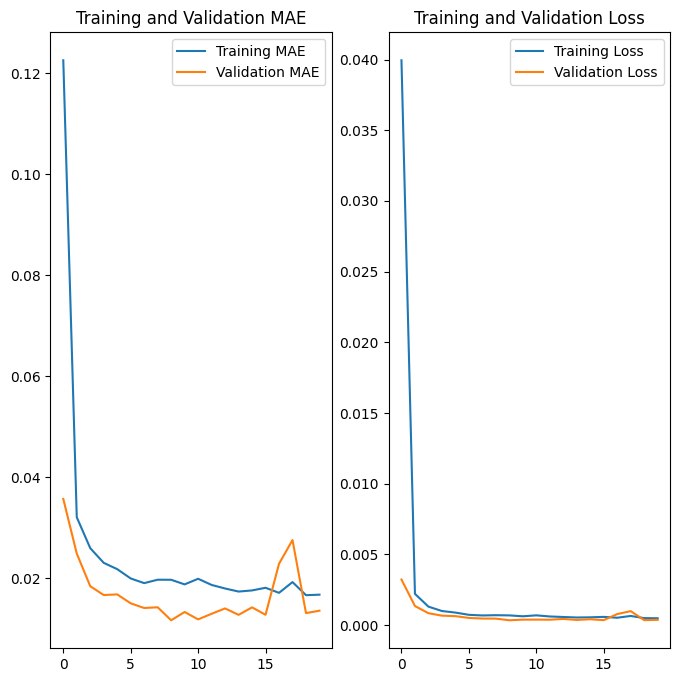

In [7]:
#Visualize results
mae = history.history['mae']
val_mae = history.history['val_mae']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, mae, label='Training MAE')
plt.plot(epochs_range, val_mae, label='Validation MAE')
plt.legend(loc='upper right')
plt.title('Training and Validation MAE')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


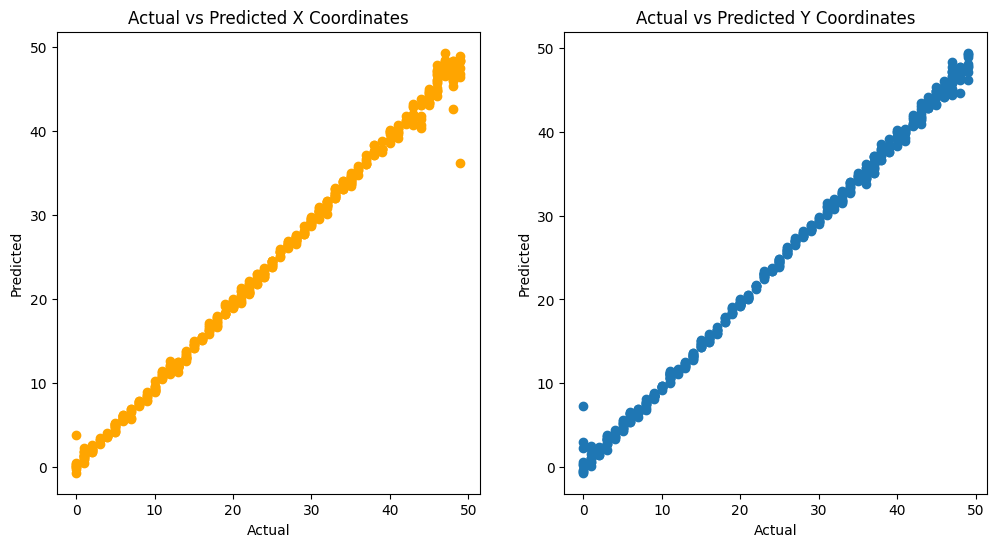

In [8]:
#Visualize predictions
with [] as y_true, [] as y_pred:
    for images, labels in test_dataset:
        preds = model.predict(images)
        y_true.append(labels.numpy())
        y_pred.append(preds)

    y_true = np.vstack(y_true) * 49
    y_pred = np.vstack(y_pred) * 49

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_true[:, 0],y_pred[:, 0], c='orange')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted X Coordinates')

    plt.subplot(1,2,2)
    plt.scatter(y_true[:,1],y_pred[:,1])
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted Y Coordinates')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


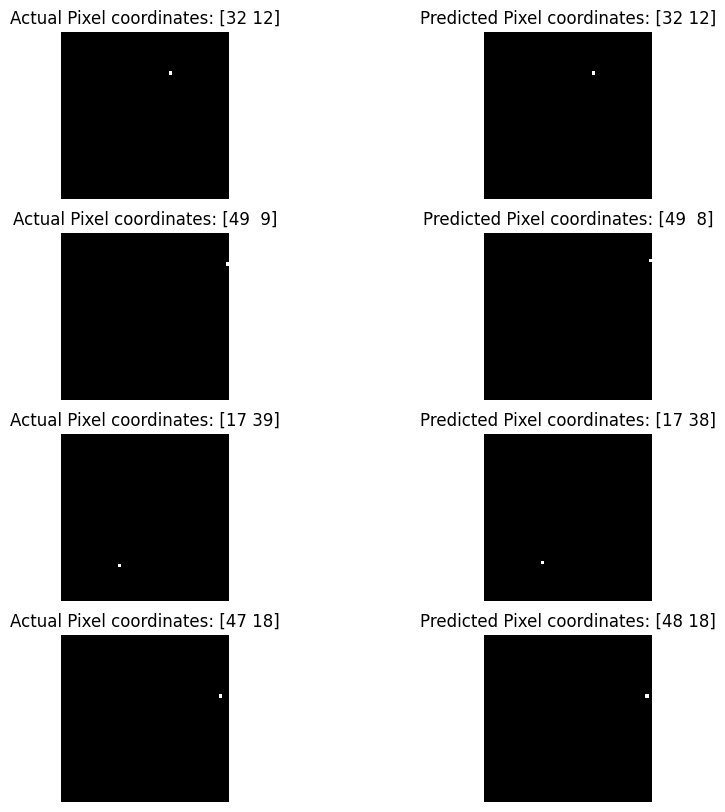

In [10]:
#Visualizing predictions for 4 samples
plt.figure(figsize=(10, 10))
for image_batch, label_batch in test_dataset.take(1):
    pred_coords = model.predict(image_batch)
    for i in range(4):
        pred = np.around(pred_coords[i] * 49).astype(np.uint8)
        pred_img = np.zeros_like(image_batch[i])
        pred_img[pred[1], pred[0]] = 1.0

        plt.subplot(4, 2, 2*i + 1)
        plt.imshow(image_batch[i], cmap='gray')
        label = np.around(label_batch.numpy() * 49)
        plt.title(f'Actual Pixel coordinates: {label[i].astype(np.uint8)}')
        plt.axis('off')

        plt.subplot(4, 2, 2*i + 2)
        plt.imshow(pred_img,cmap='gray')
        plt.title(f'Predicted Pixel coordinates: {pred}')
        plt.axis('off')

## Results
The CNN model is trained to fit the dataset

> Mean Absolute Error (MAE) = **0.0174** (during *training*) and **0.0136** (during *validation*)

The model can predict the pixel coordinate with (±1px, ±1px) error in general.